In [1]:
import heavystats as hs

df = hs.load_data()

df_procesado = hs.standardize_boolean_columns(df)

# 3. Desagregar respuestas múltiples (creará las columnas binarias _Caminar, _Vehiculo, etc.)
df_procesado = hs.desaggregate_multiple_responses(
    df_procesado, 
   columns=["Salud_Transporte", "Salud_Agua", "Exposicion_Talleres", "Exposicion_Lugares"]
)

# 4. Codificar frecuencias alimentarias (cambiará "Diario", "Nunca" por 4, 0, etc.)
df_procesado = hs.encode_dietary_frequencies(df_procesado)

# 5. Seleccionar el metal (conservará las transformaciones anteriores)
df_pb = hs.select_metal(df_procesado, concentration_col="plomo")

In [2]:
from heavystats.univariate import UnivariatePlots
import matplotlib.pyplot as plt

# Inicializar con tu DataFrame (por ejemplo, df_pb)
uplots = UnivariatePlots(df_pb, palette="crest")


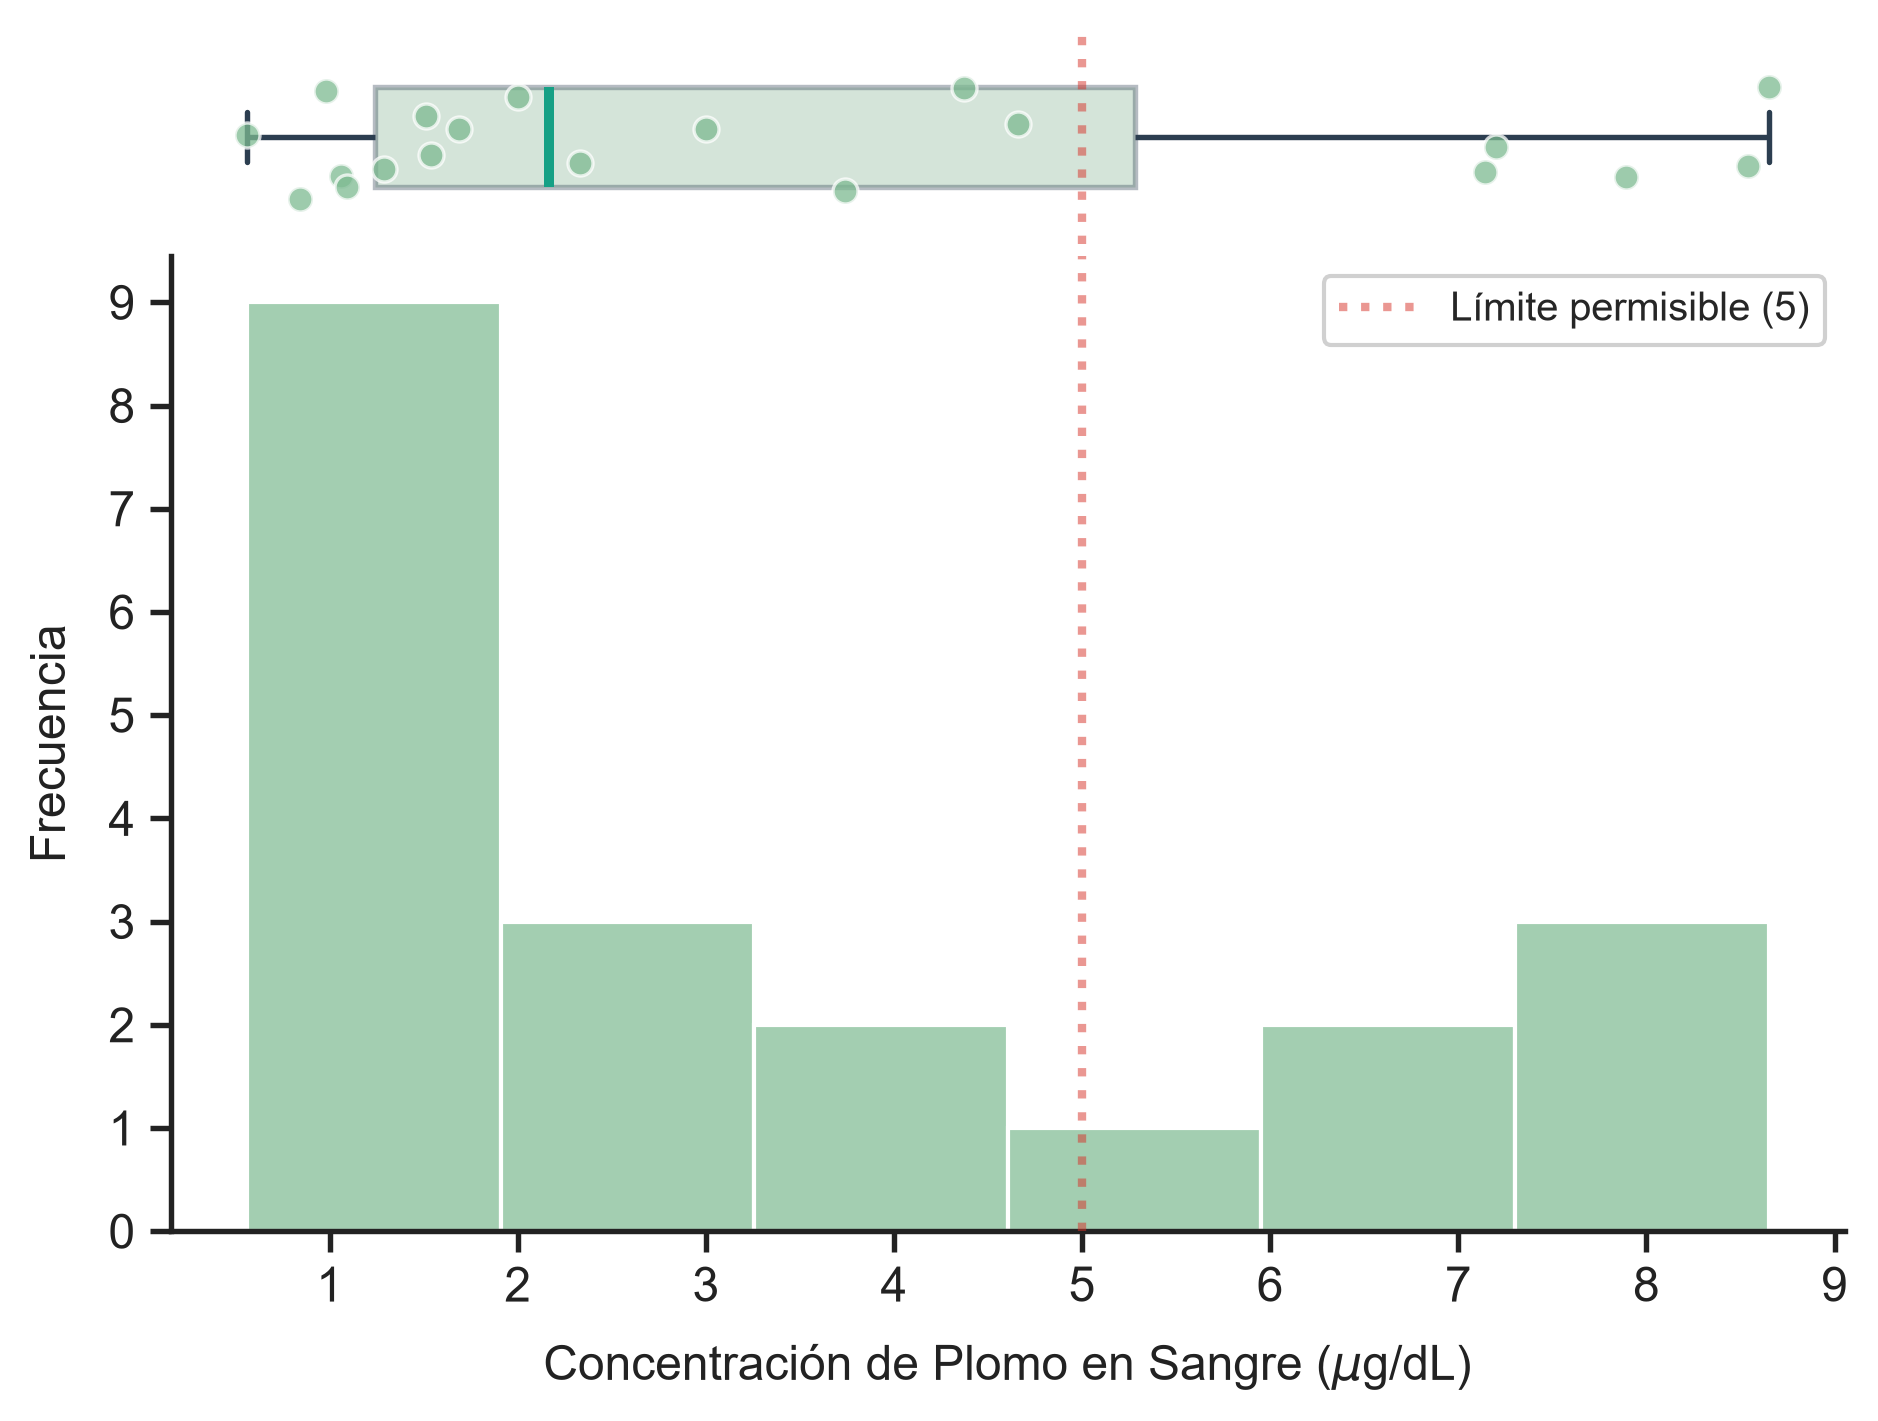

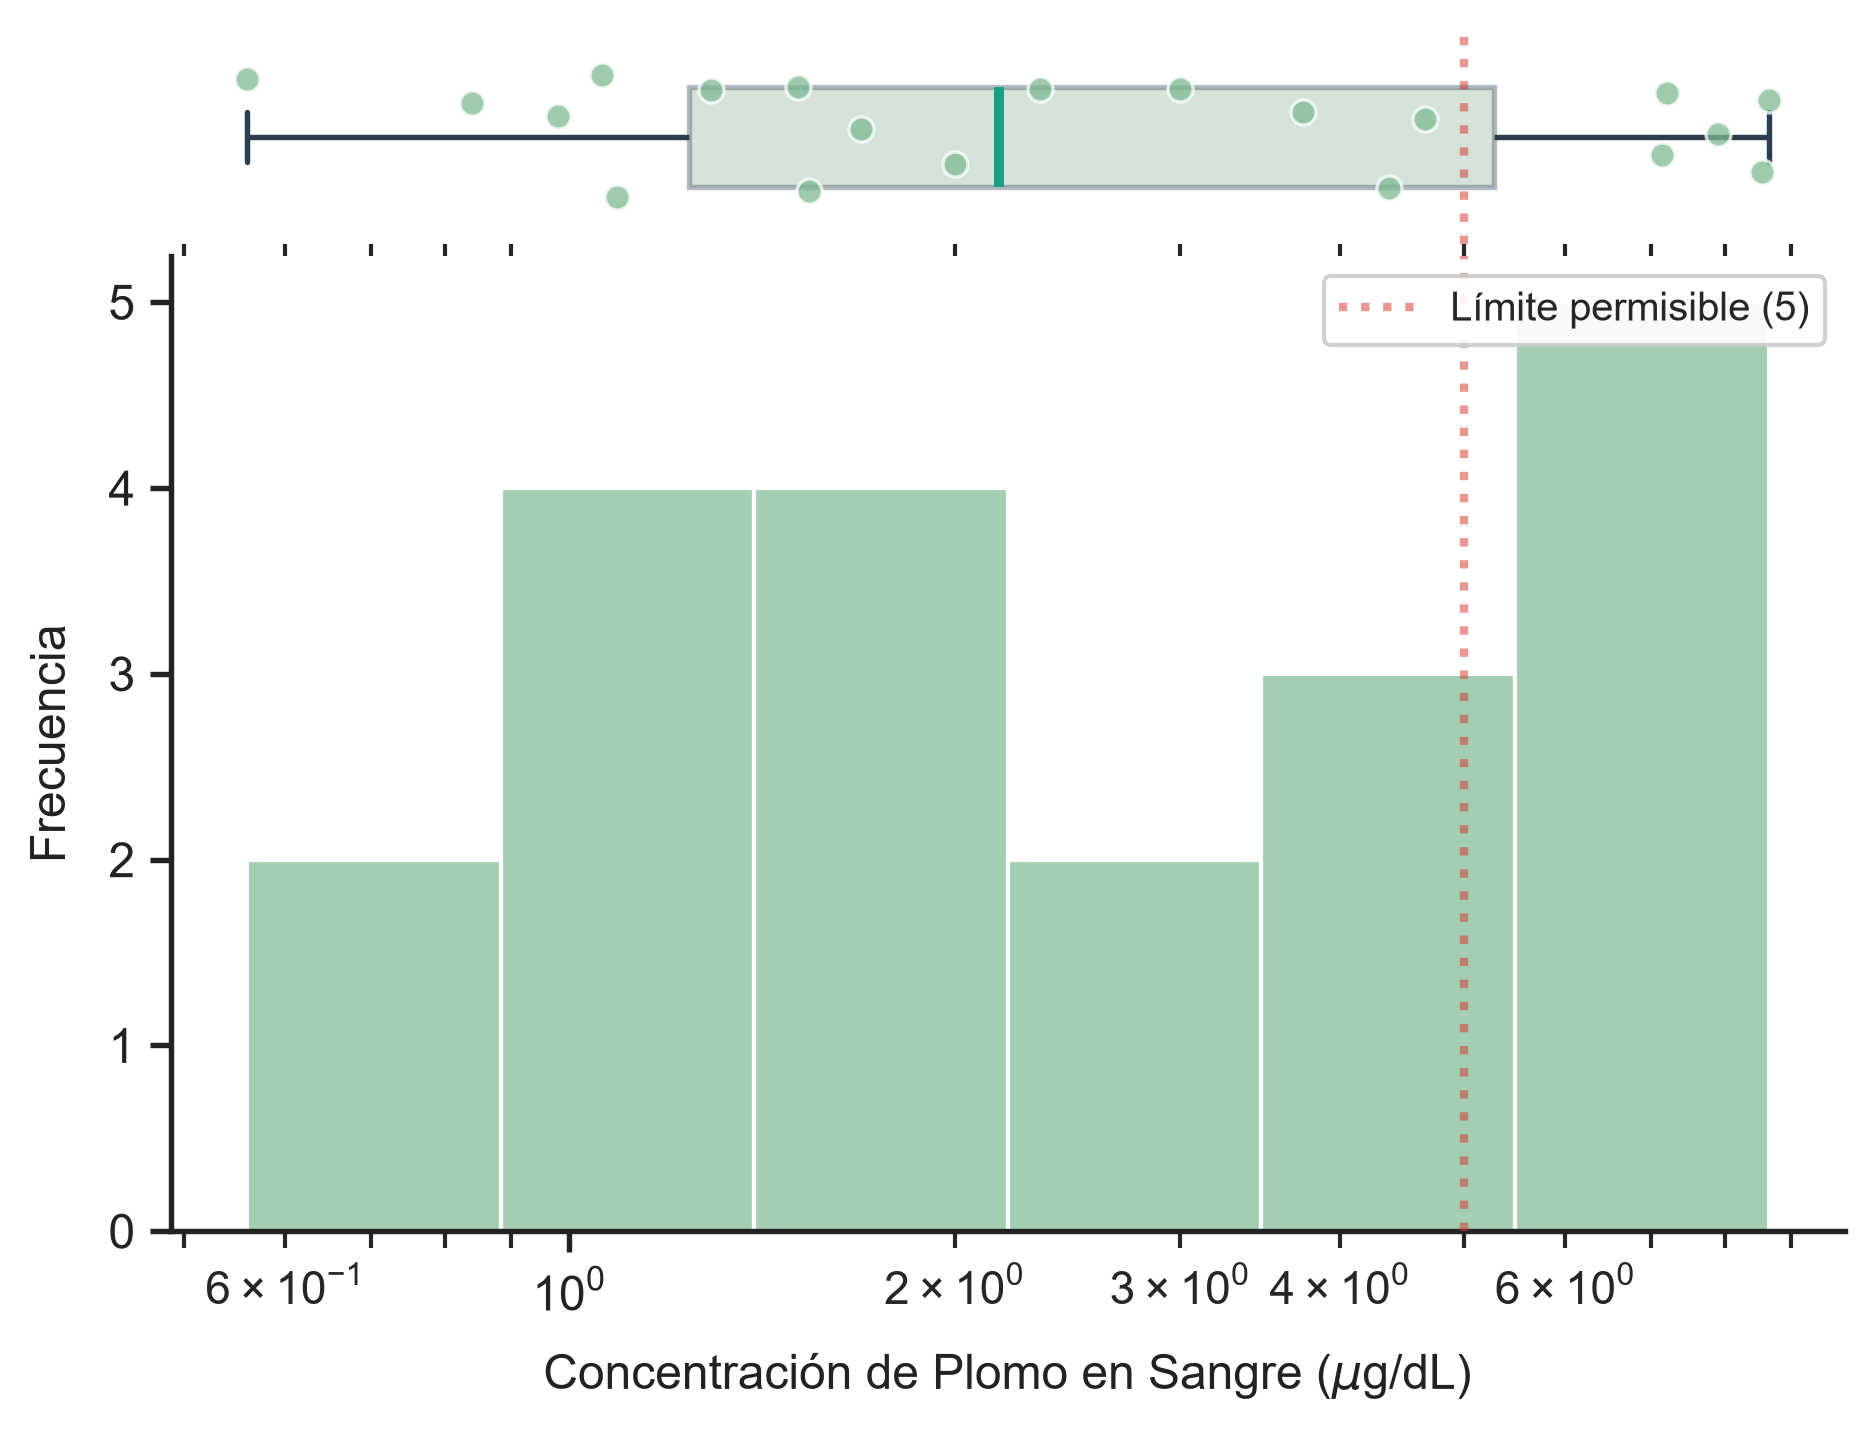

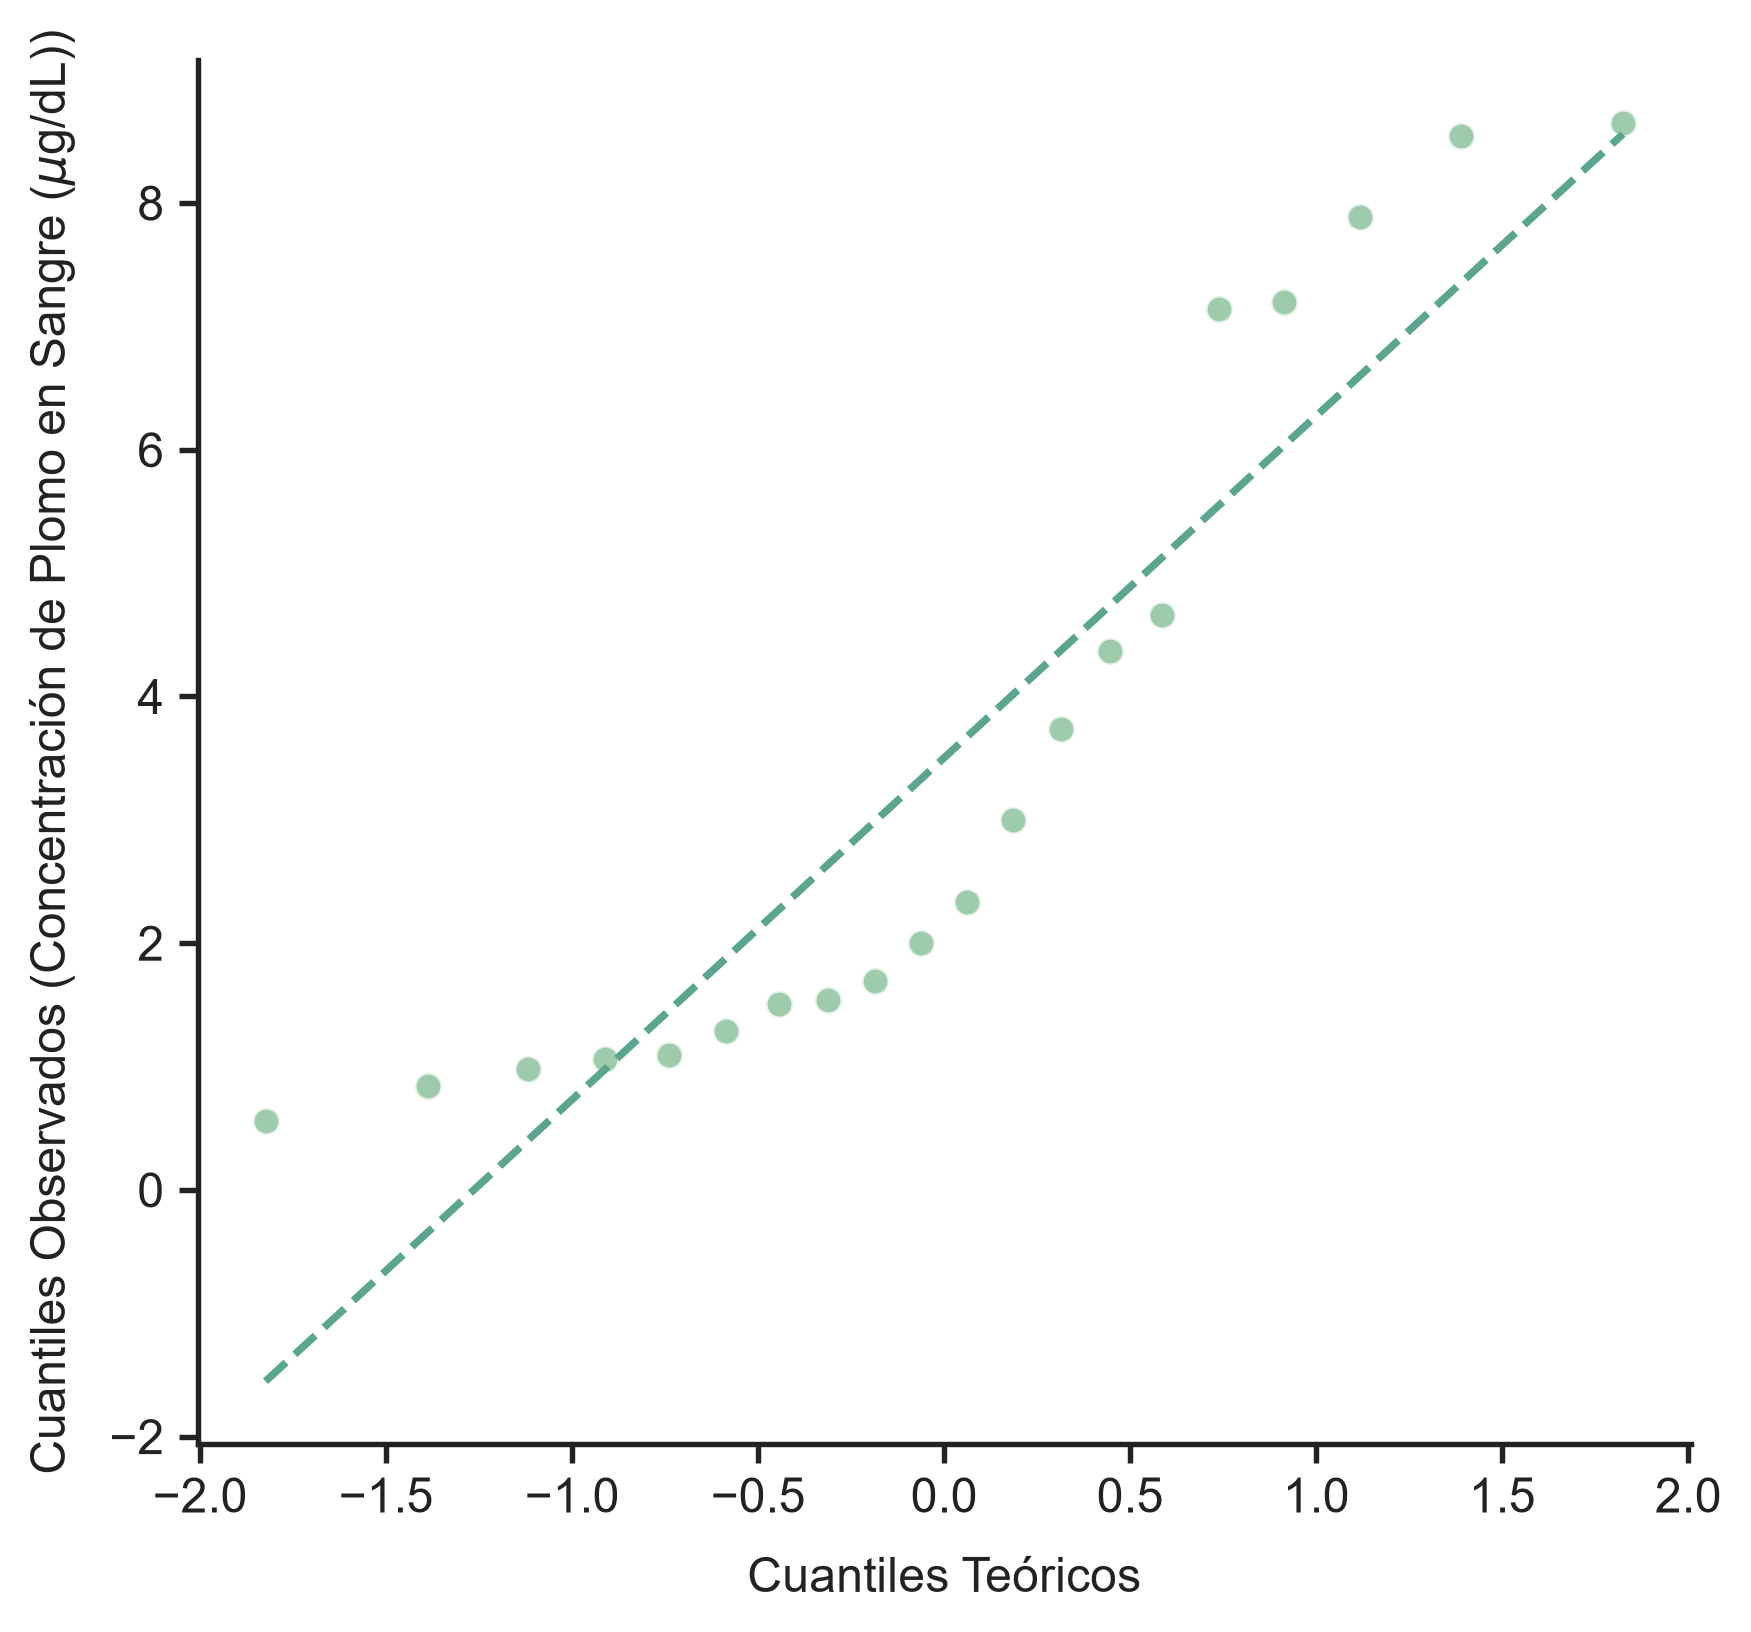

In [3]:
# Versión estándar con límite permisible de referencia en sangre (alpha=0.5)
uplots.plot_box_histograms("Plomo_ug_dL", show_limit=True);

# Versión con escala logarítmica coordinada (recomendado para metales pesados asimétricos)
uplots.plot_box_histograms("Plomo_ug_dL", log_scale=True, show_limit=True);

uplots.plot_qq("Plomo_ug_dL");



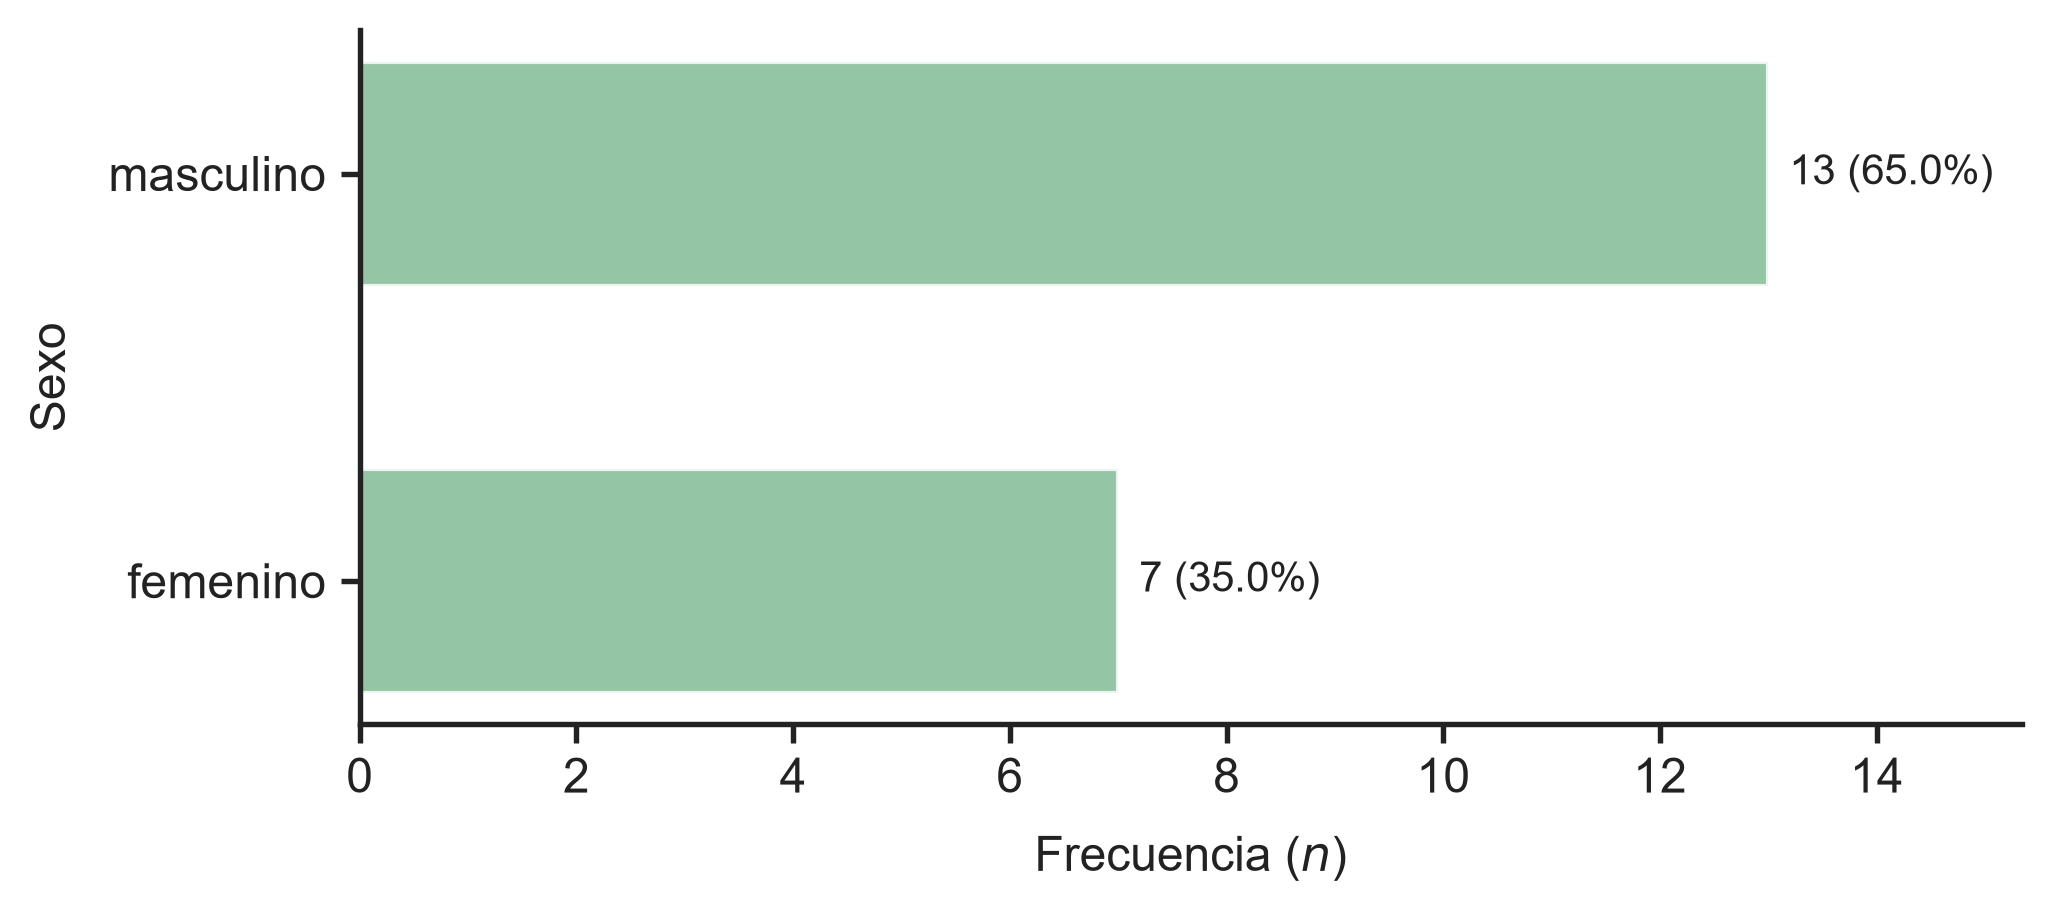

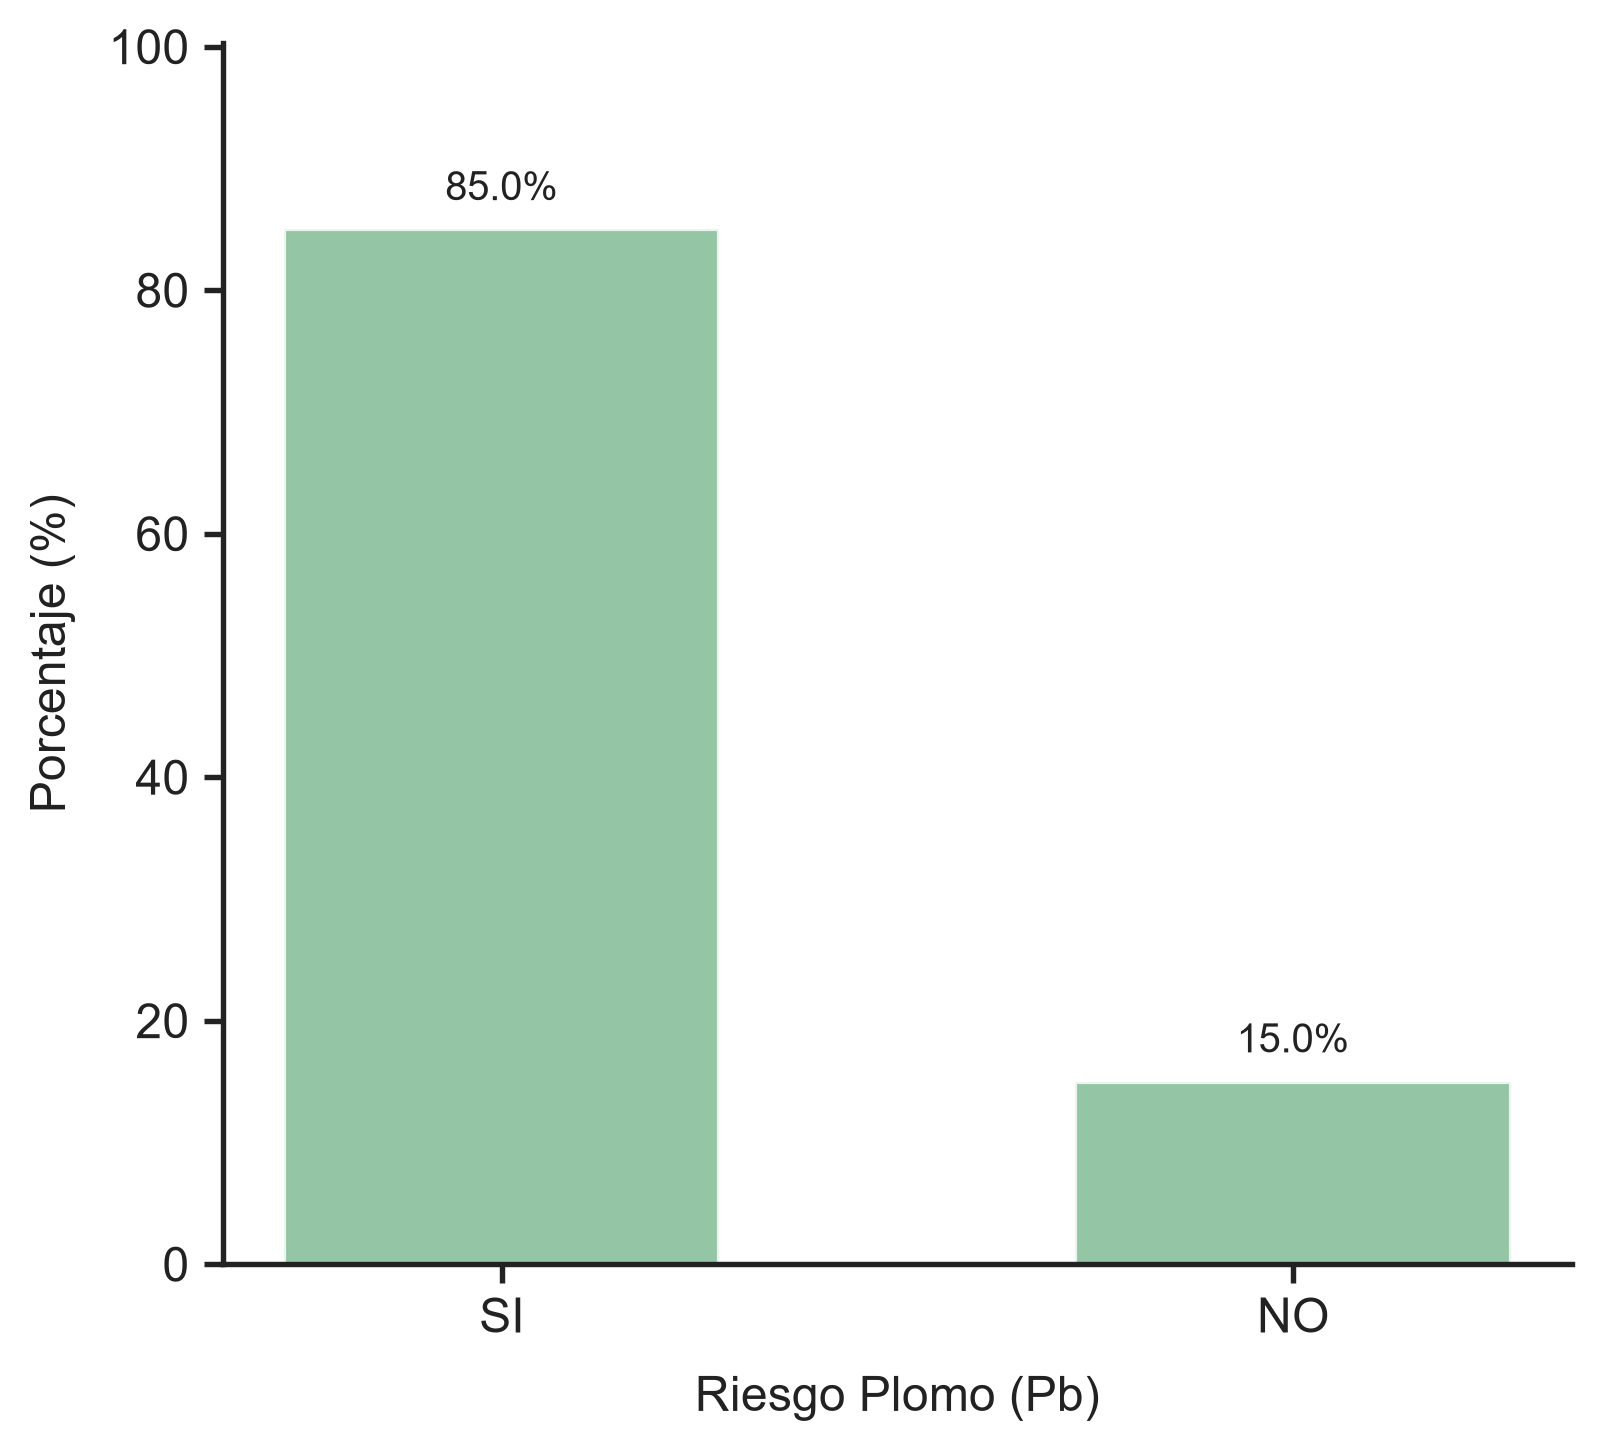

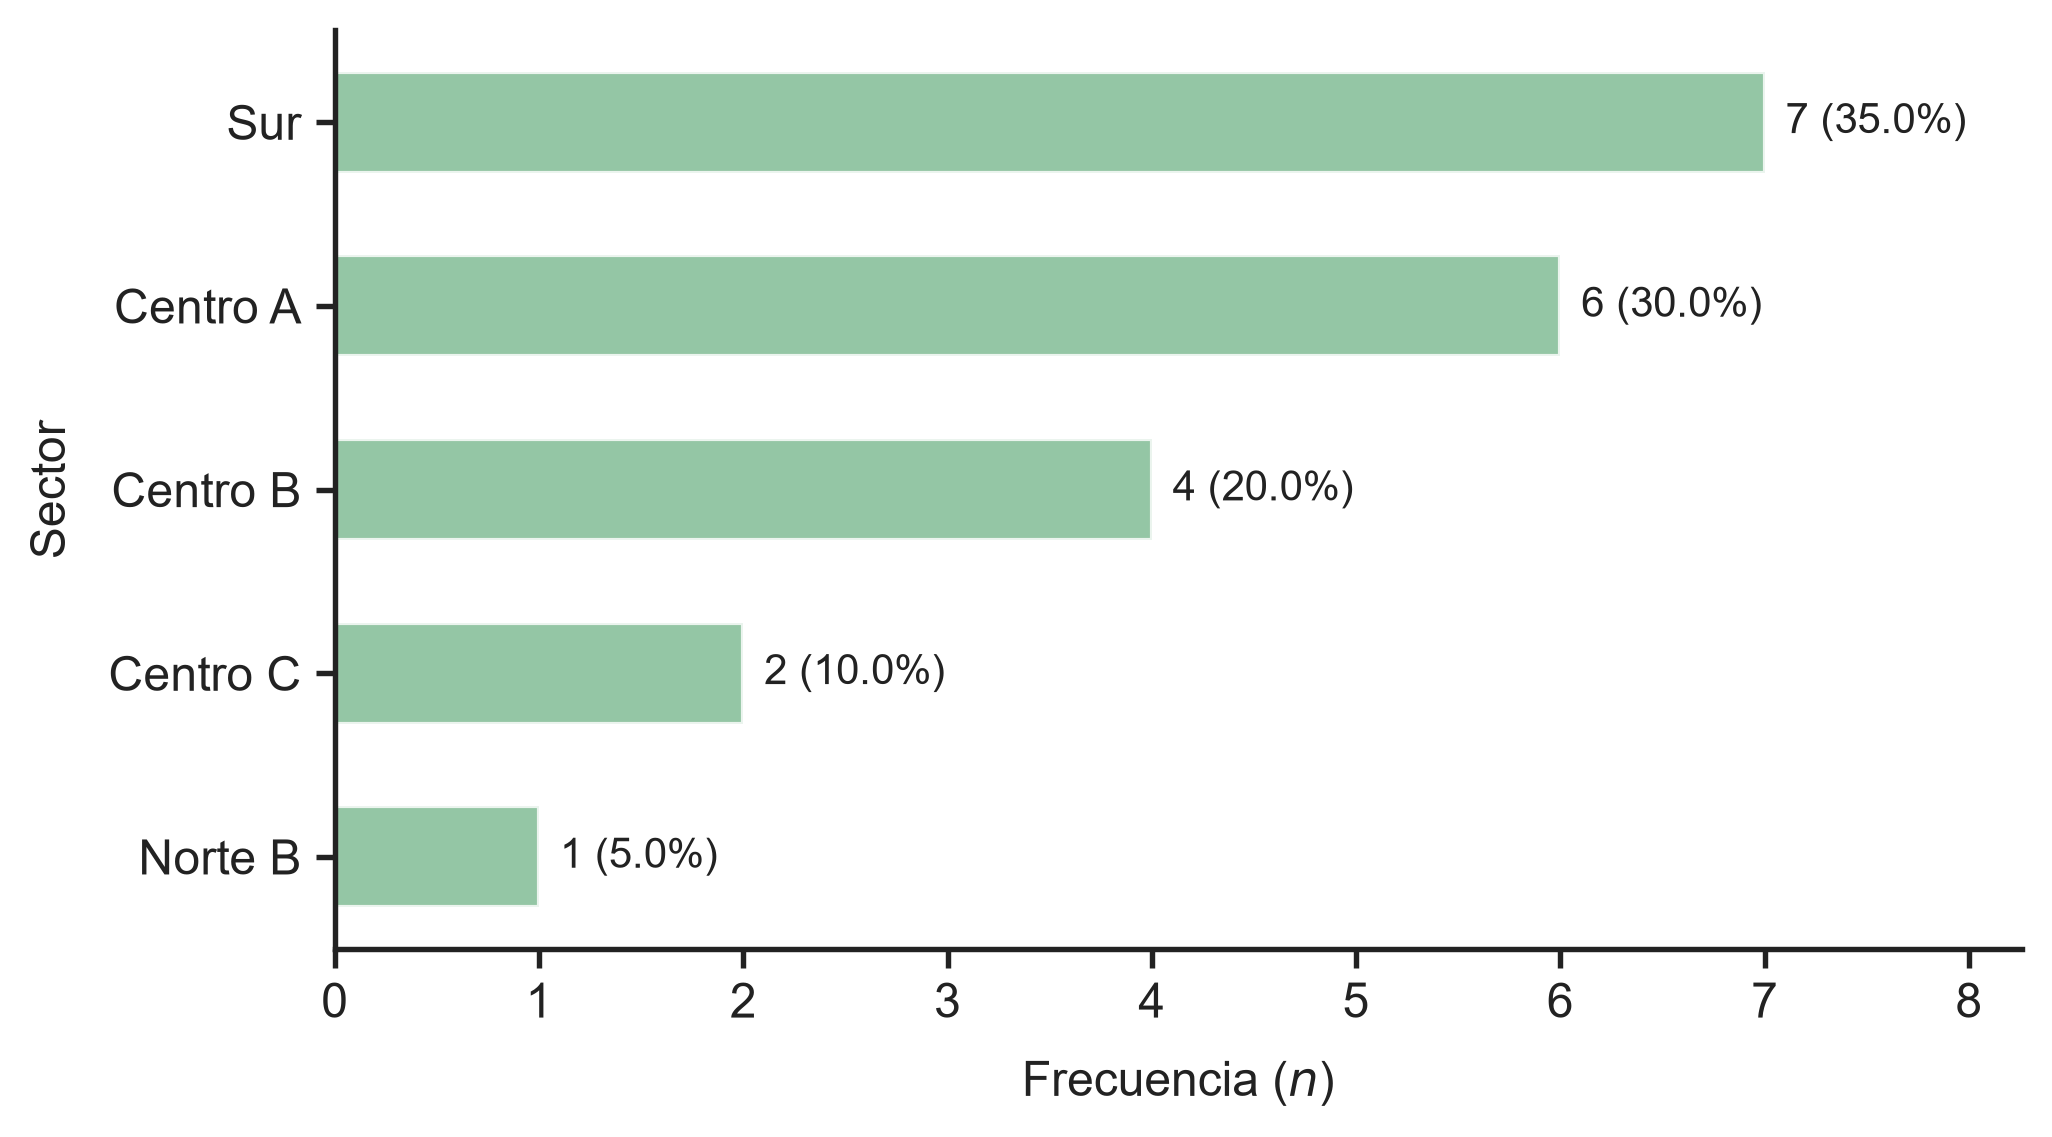

In [4]:
# Barras horizontales con etiquetas n y % automáticas
uplots.plot_categorical("Sexo");

# Barras verticales con porcentaje puro (%)
uplots.plot_categorical("Riesgo_Pb", orientation="vertical", as_percentage=True);

# Ordenar alfabéticamente o por frecuencia descendente
uplots.plot_categorical("Sector", order="frequency");


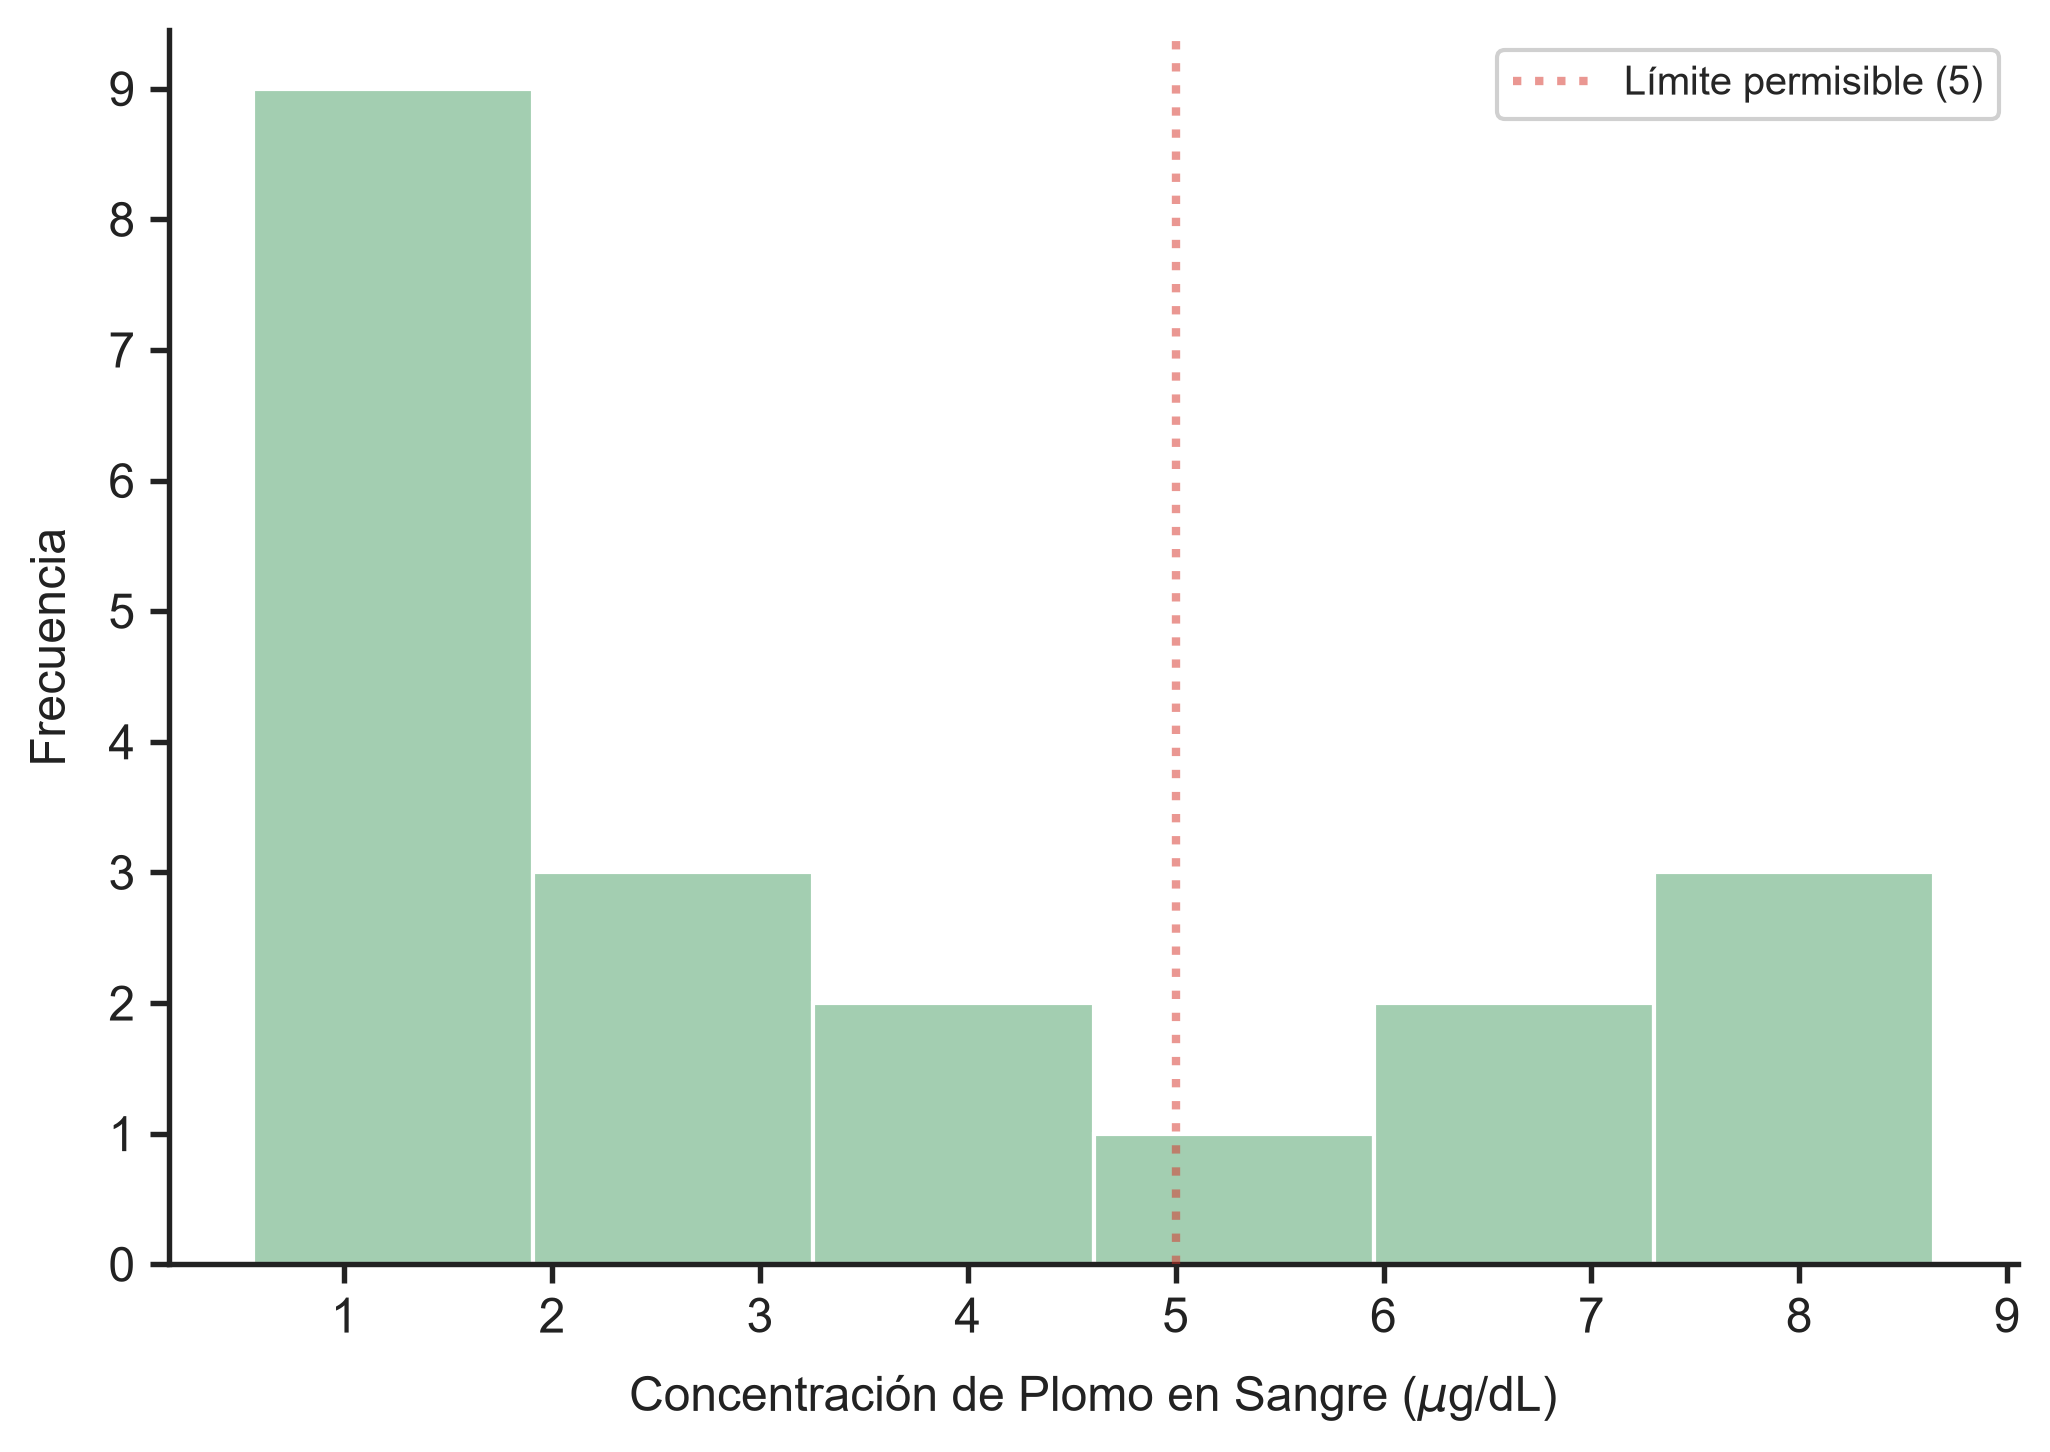

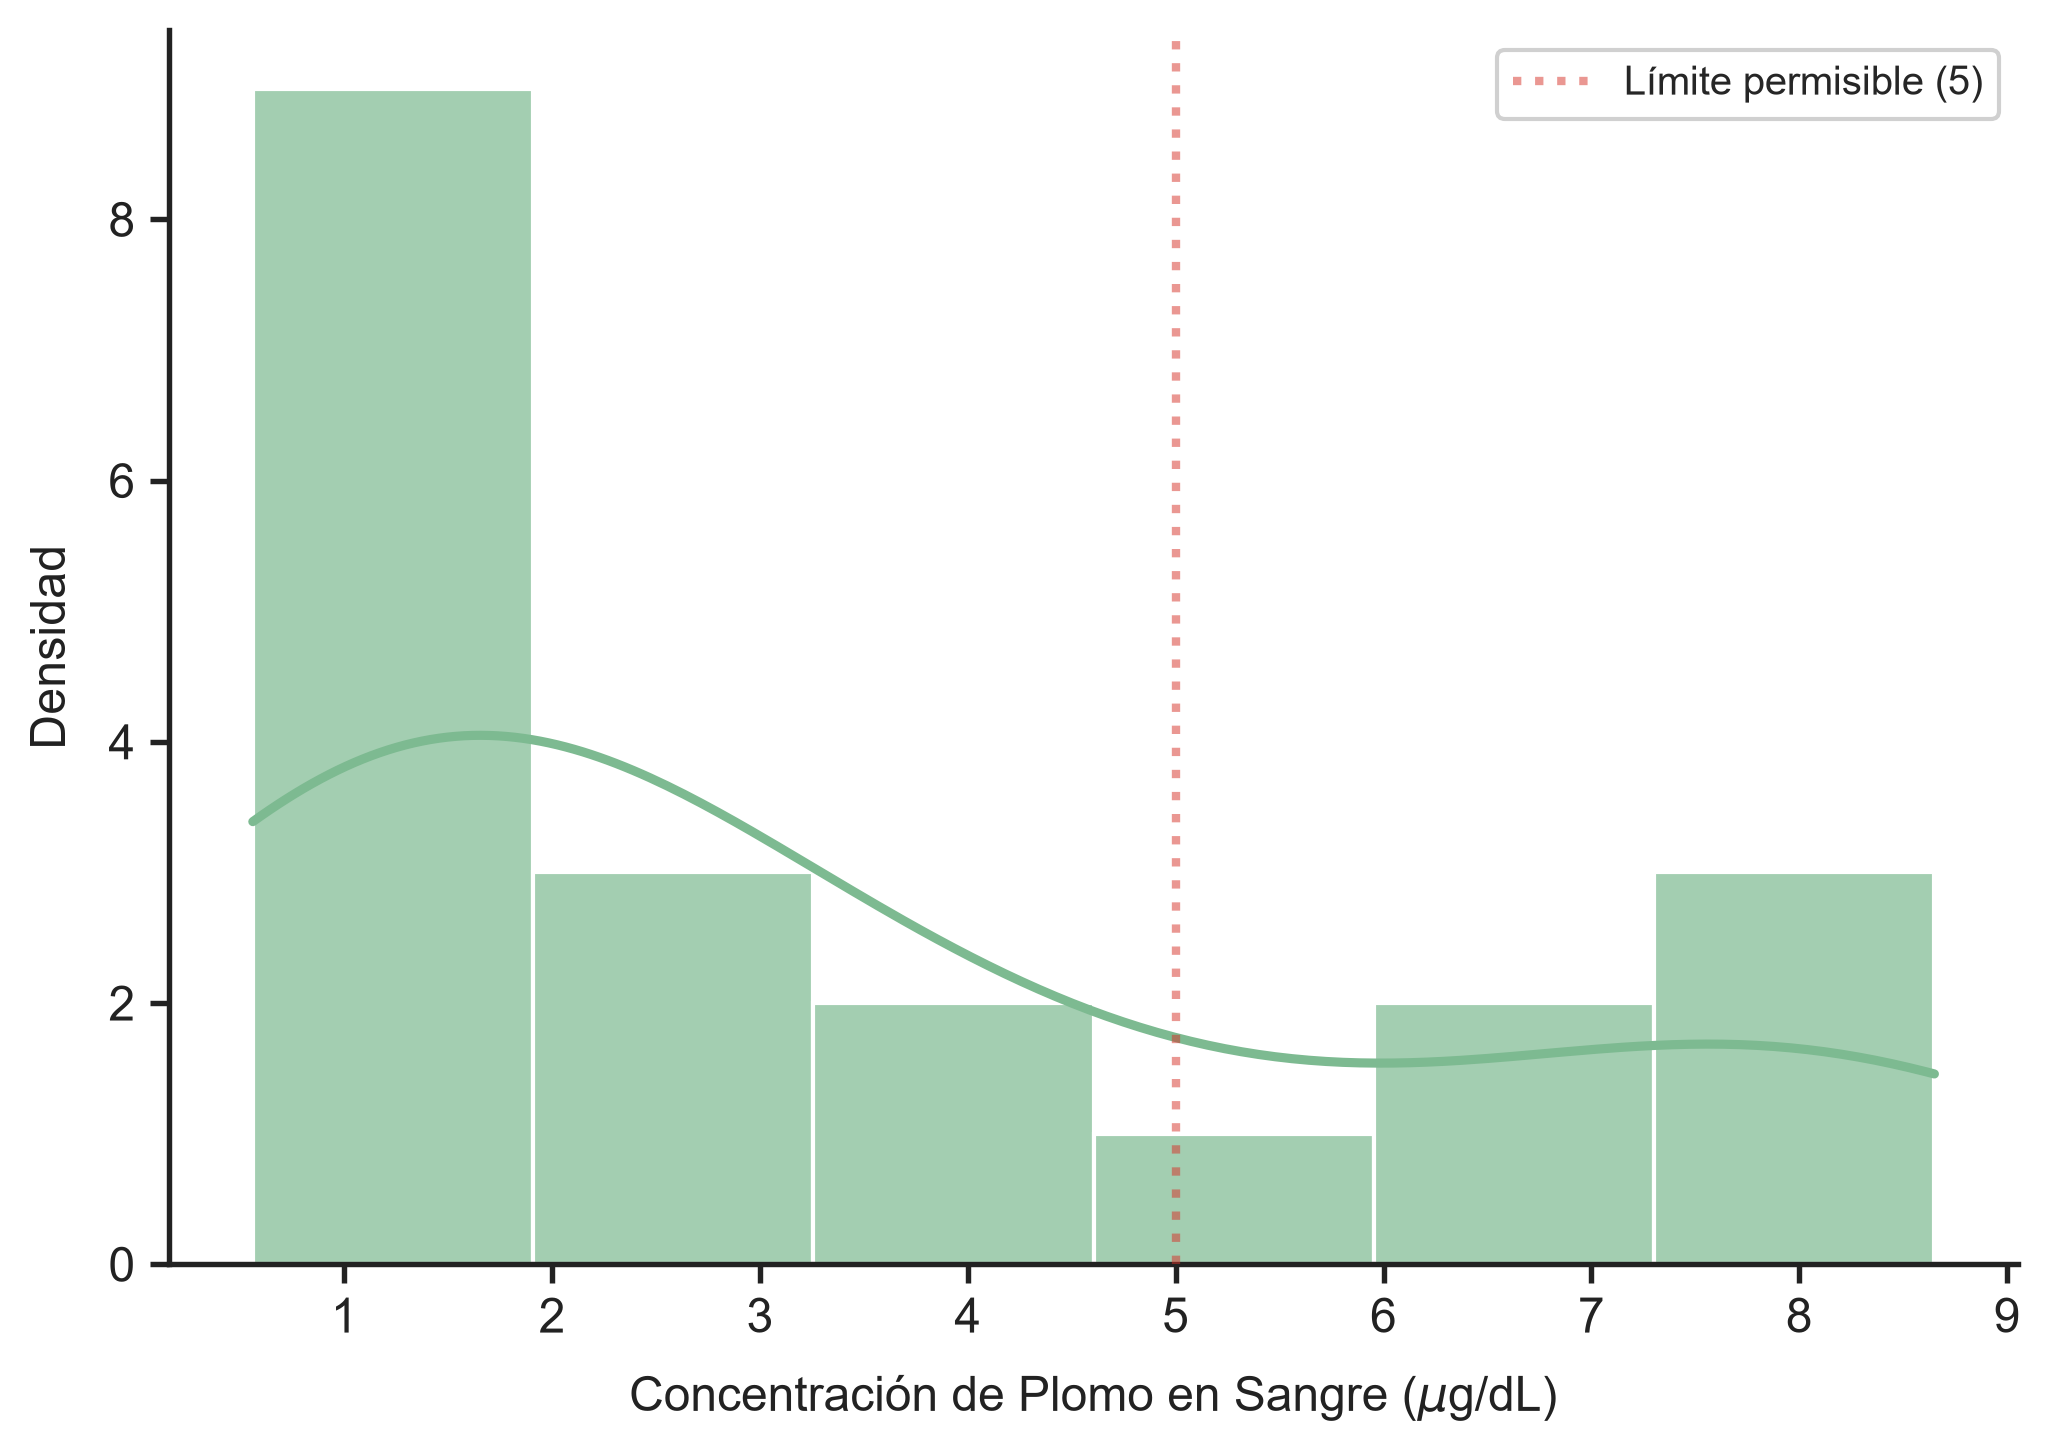

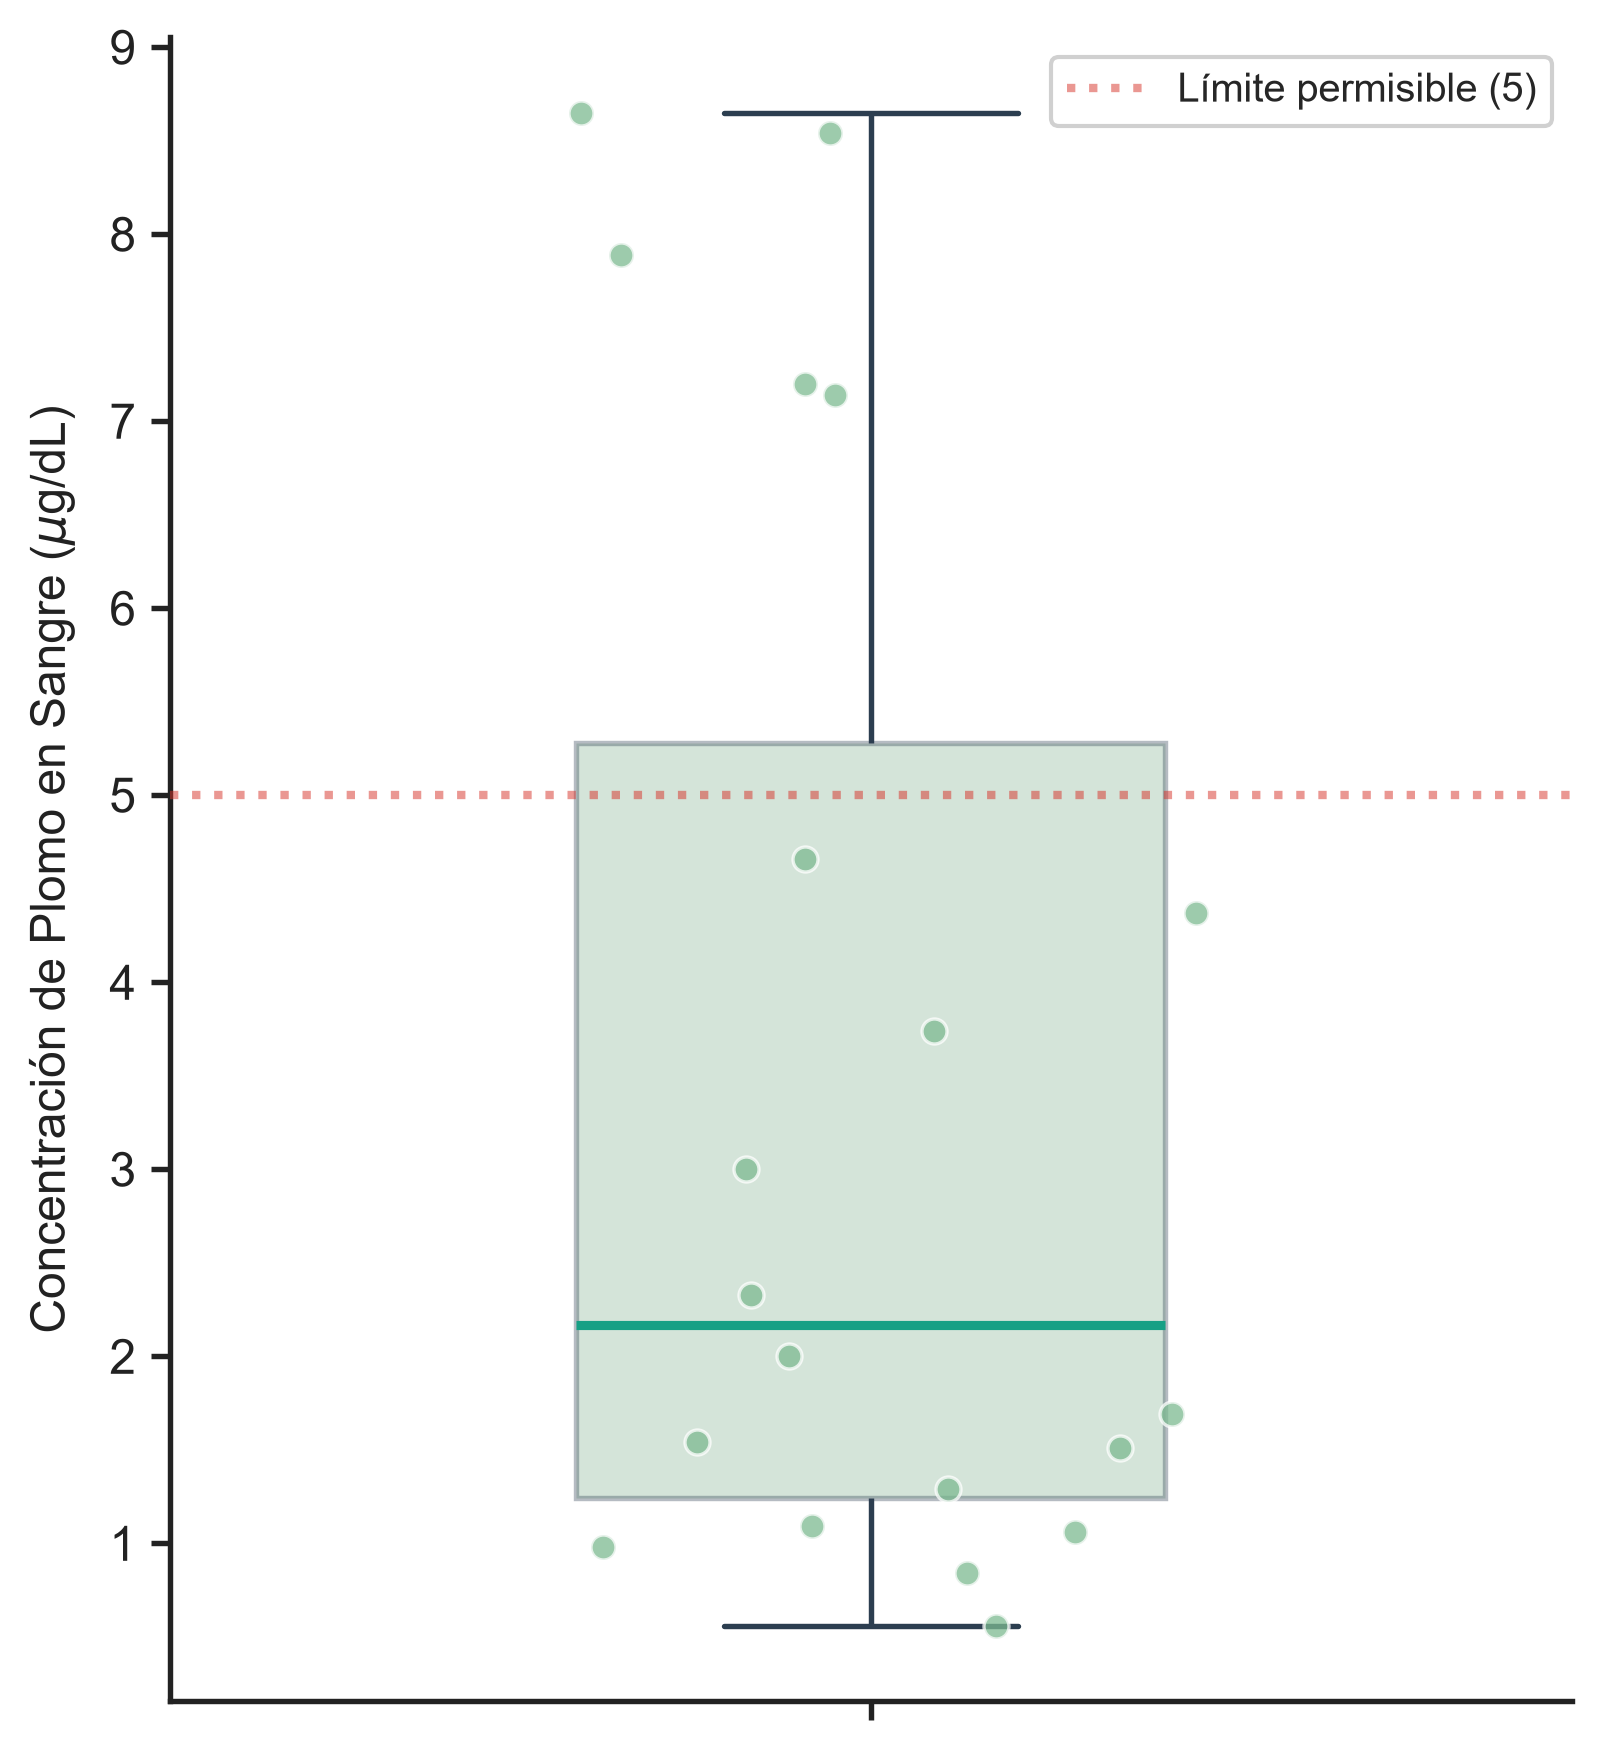

In [5]:
# Histograma simple con conteos enteros
uplots.plot_histograms("Plomo_ug_dL", show_limit=True);

# Histograma con curva de densidad suave (KDE)
uplots.plot_histograms("Plomo_ug_dL", kde=True, show_limit=True);

# Boxplot vertical con dispersión de puntos individuales (stripplot)
uplots.plot_boxplots("Plomo_ug_dL", show_limit=True);


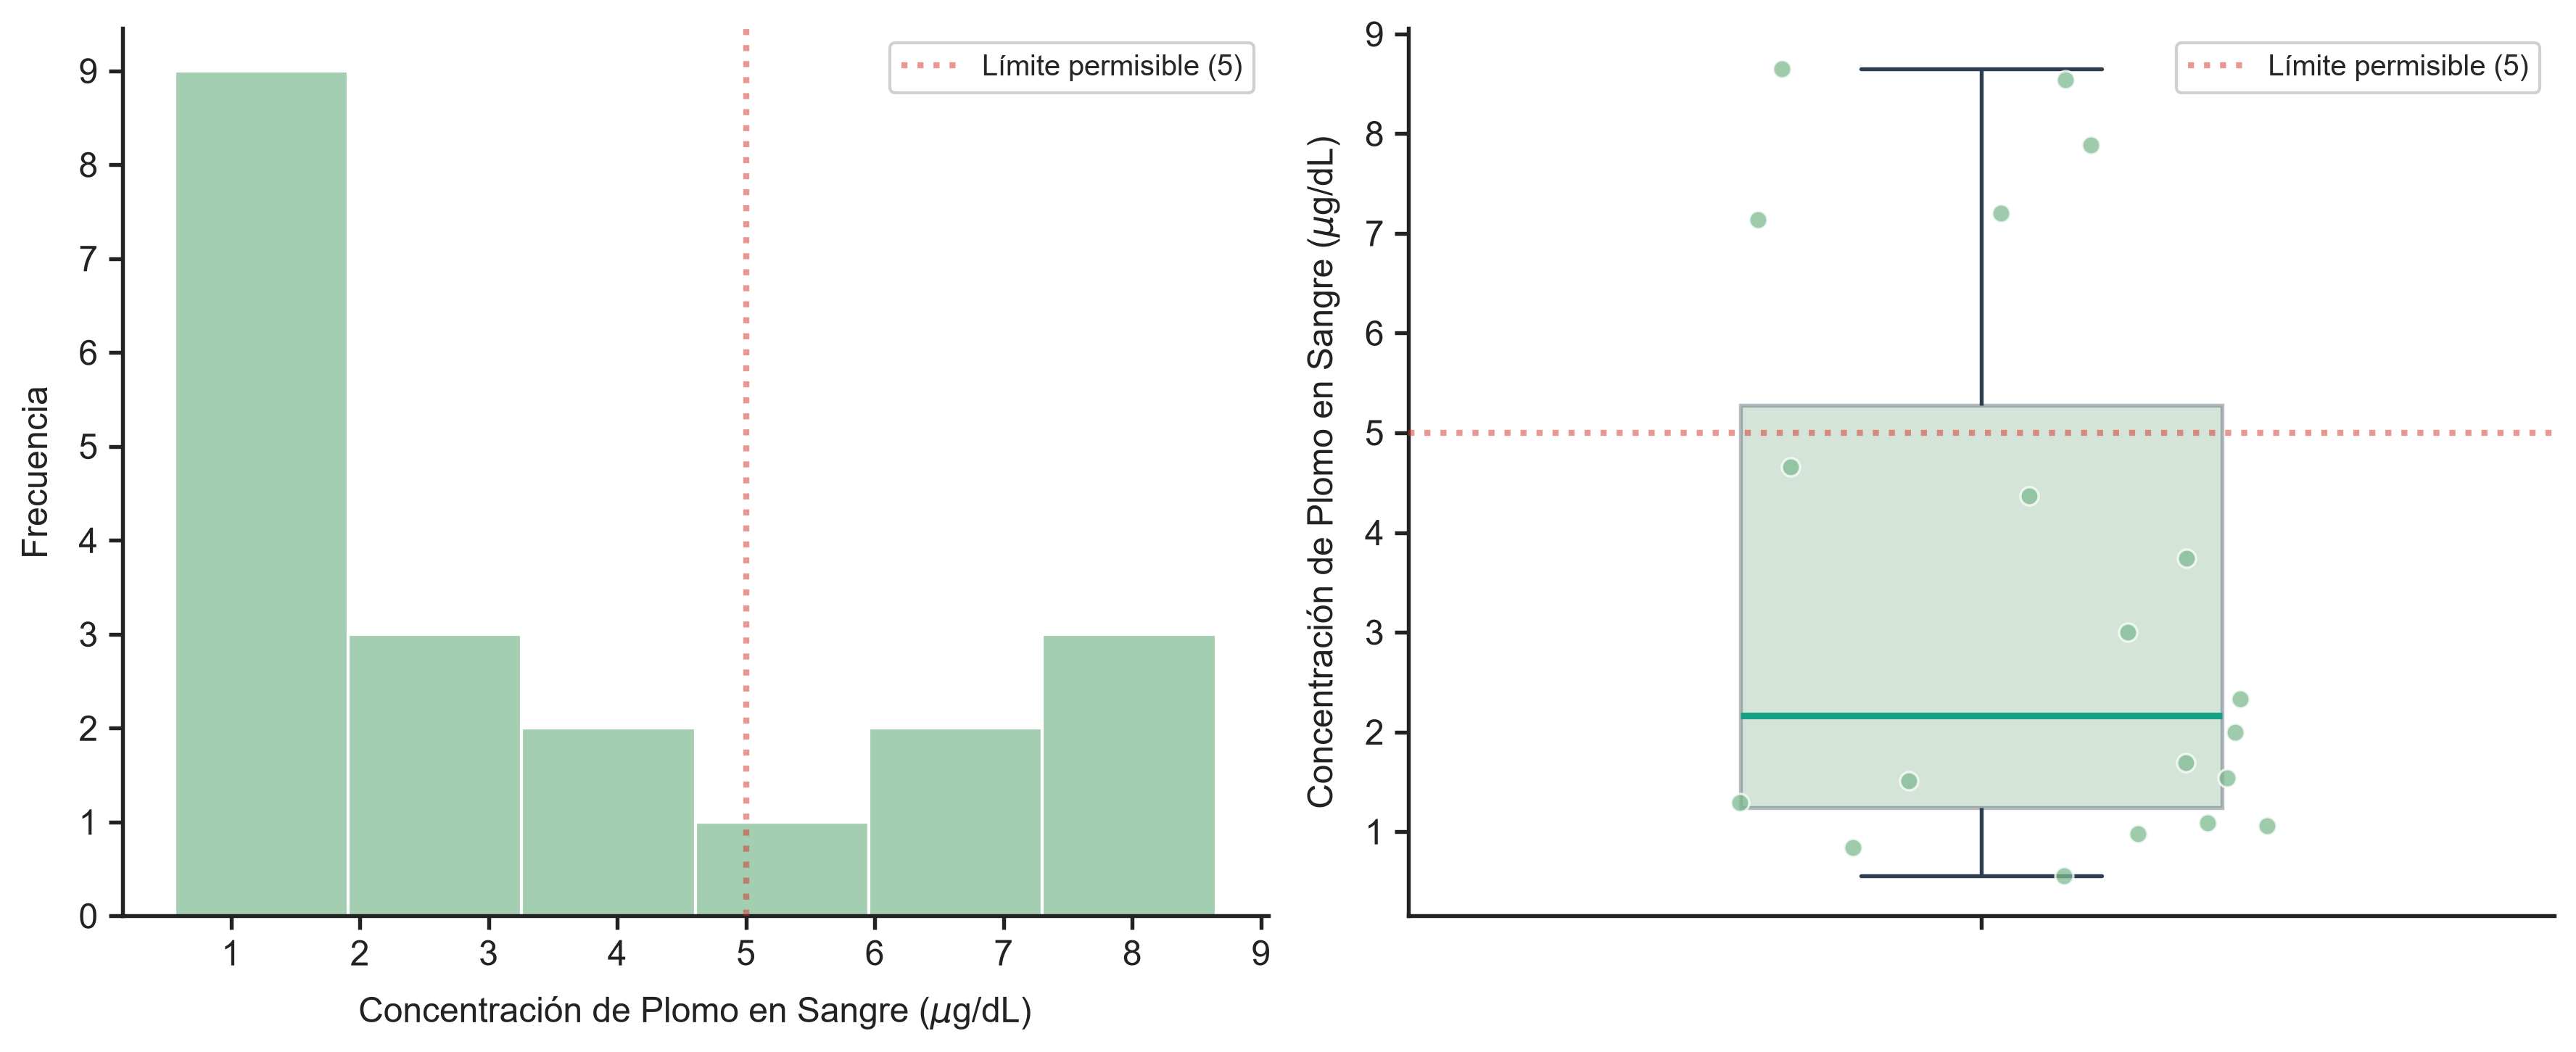

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma a la izquierda y Boxplot a la derecha
uplots.plot_histograms("Plomo_ug_dL", ax=axes[0], show_limit=True)
uplots.plot_boxplots("Plomo_ug_dL", ax=axes[1], show_limit=True)

plt.tight_layout();
